## BBM 409 - Programming Assignment 3

* You can add as many cells as you want in-between each question.
* Please add comments to your code to explain your work.  
* Please add Markdown cells to answer the (non-coding) questions in the homework text. You can, however, refer to the outputs of code cells without adding them as images to the Markdown cell unless you are requested to do otherwise.
* Please be careful about the order of runs of cells. Doing the homework, it is likely that you will be running the cells in different orders, however, they will be evaluated in the order they appear. Hence, please try running the cells in this order before submission to make sure they work.    
* Please refer to the homework text for any implementation detail. Though you are somewhat expected to abide by the comments in the below cells, they are mainly just provided for guidance. That is, as long as you are not completely off this structure and your work pattern is understandable and traceable, it is fine. For instance, you do not have to implement a particular function within a cell just because the comment directs you to do so.
* This document is also your report. Show your work.

###  Mustafa Emir Tezcan - 2230356092

## 1. Implementing a CNN from Scratch (40 points)

### 1.1. Introduction
**Brief overview of the task.**

**Answer the questions like, What are the main components of a CNN architecture?, Why we use this in image classification?, etc.**

**Description of the dataset used for classification.**

* The primary objective of this assignment is to design and implement a Convolutional Neural Network (CNN) model from scratch using the PyTorch deep learning framework. The goal is to accurately classify images belonging to various vegetable species. This task involves constructing a custom CNN architecture without relying on pre-trained models, thereby facilitating a deeper understanding of the fundamental components of deep learning pipelines, including model construction, training loops, and evaluation metrics.

* A basic CNN architecture is composed of four main components: convolutional layers, pooling layers, activation functions, and fully connected layers. CNNs are used in image classification tasks because they are specifically designed to process data with a grid-like topology, such as images. Unlike traditional fully connected networks that treat input pixels as independent features, CNNs preserve the spatial relationships between pixels. Through the use of learnable filters (kernels) in convolutional layers, the network is able to automatically extract hierarchical features—ranging from simple edges and textures in early layers to complex shapes and object parts in deeper layers. Pooling layers further aid this process by reducing dimensionality and making the model invariant to small translations and distortions in the input.
* To facilitate this task, we utilize a subset of the Vegetable Image Dataset. This dataset contains a total of 4,500 images categorized into 15 distinct classes corresponding to different vegetable species. To ensure balanced and fair training, the dataset is stratified equally into 3,000 training images (200 per class), 750 validation images (50 per class), and 750 testing images (50 per class).



### 1.2. Data Loading and Preprocessing (3 points)

In [46]:
## Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import pandas as pd
import glob
from PIL import Image
from torch.utils.data import Dataset

In [47]:
## Load the dataset using PyTorch's data loading utilities
## Apply necessary preprocessing such as resizing and normalization
## Divide the dataset into training, validation, and testing subsets
transformations = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(10), # for preventing overfitting # preventing memorization of training data
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # normalize to -1,1
])
train_dataset= ImageFolder(root='./pa3_subset/train', transform=transformations)
val_dataset = ImageFolder(root='./pa3_subset/val', transform=transformations)
def set_seed(seed): # for reproducibility
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

### 1.3. Define your CNN architecture (7 points)

**Explain the reason behind your architecture.**

**Explain your choice of activation functions.**

* The architecture is a  Convolutional Neural Network designed to classify images into 15 distinct categories. The design philosophy centers on a Dual-Pooling Strategy combined with incremental feature expansion. Unlike standard architectures that typically increase channel depth purely through convolutional layers, this model leverages the concatenation of pooling outputs to expand the feature space while reducing spatial dimensions.The architecture consists of five convolutional blocks, followed by a fully connected classifier. Standard CNNs usually force a choice between Max Pooling (which preserves the most prominent features, like sharp edges) and Average Pooling (which retains background information and smooths the features). The most distinctive feature of this architecture is the Dual-Pooling Strategy. By calculating both and concatenating them along the channel dimension, the network preserves both high-frequency texture details and low-frequency background information. This concatenation also serves as the mechanism for channel expansion (doubling the depth at each stage), preparing the feature map for the subsequent layer without requiring the convolution itself to double the parameters.

* The first layer uses a larger kernel size (5). This is chosen to capture broader, low-level spatial features from the raw input image immediately.The following layers utilize smaller 3x3 kernels for capturing local patterns.

* Batch normalization is applied immediately after every convolution and before activation. This normalizes the distribution of layer inputs, stabilizing the learning process. It allows for higher learning rates and significantly reduces the network's sensitivity to weight initialization.
* A dropout rate of p=0.5 is applied before the final fully connected layer. This randomly zeroes out 50% of the neurons during training, forcing the network to learn redundant representations and preventing overfitting to the training data.
* The architecture employs the ReLU activation function primarily to mitigate the vanishing gradient problem, allowing the deep network to converge significantly faster than with saturating functions like Sigmoid. By introducing non-linearity without capping positive values, ReLU enables the model to learn complex feature boundaries efficiently, while also promoting sparsity by outputting zero for negative inputs, which optimizes computational resources.

In [48]:
## Design a CNN architecture with at least 3 and at most 6 convolutional layers
## Add activation functions (e.g., ReLU) after each convolutional layer
## Intersperse pooling layers (e.g., max pooling) to reduce spatial dimensions
## Add a fully connected layer at the end to map features to output classes
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2) # kernel size=5 for first layer
        self.bnorm1 = nn.BatchNorm2d(16) # Batch normalization

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1) # kernel size=3 for other layers
        self.bnorm2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bnorm3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bnorm4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bnorm5 = nn.BatchNorm2d(256)

        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2) # Max pooling layer
        self.avg_pool = nn.AvgPool2d(kernel_size=2, stride=2) # Average pooling layer

        self.dropout = nn.Dropout(p=0.5) # Dropout layer for regularization

        self.fc = nn.Linear(512 * 8 * 8, 15) # Fully connected layer for 15 classes
    def forward(self,x):
        x = torch.relu(self.bnorm1(self.conv1(x))) # Convolution + BatchNorm + ReLU
        x = torch.cat((self.max_pool(x), self.avg_pool(x)), dim=1) # Dual pooling and concatenation

        x = torch.relu(self.bnorm2(self.conv2(x)))
        x = torch.cat((self.max_pool(x), self.avg_pool(x)), dim=1)

        x = torch.relu(self.bnorm3(self.conv3(x)))
        x = torch.cat((self.max_pool(x), self.avg_pool(x)), dim=1)

        x = torch.relu(self.bnorm4(self.conv4(x)))
        x = torch.cat((self.max_pool(x), self.avg_pool(x)), dim=1)

        x = torch.relu(self.bnorm5(self.conv5(x)))
        x = torch.cat((self.max_pool(x), self.avg_pool(x)), dim=1)

        x = x.view(x.size(0), -1) # Flatten the output for the fully connected layer

        x = self.dropout(x)  # Apply dropout for regularization
        x = self.fc(x) # Fully connected layer
        return x

### 1.4 Prepare the model for training (3 points)
**Explain your choice of loss functions and optimization algorithms.**

* For the loss function, Cross-Entropy Losss was selected as the objective function, given its suitability for multi-class classification tasks. This function combines LogSoftmax and Negative Log Likelihood Loss into a single module, providing numerical stability while effectively quantifying the divergence between the predicted probability distribution and the actual class labels. By heavily penalizing confident but incorrect predictions, the cross-entropy loss drives the network to maximize the log-likelihood of the correct class, resulting in faster convergence and higher classification accuracy compared to regression-based loss functions like Mean Squared Error.

* The model parameters are updated using the Adam optimizer, chosen for its efficiency in handling sparse gradients and its ability to adapt learning rates for individual parameters. Furthermore, a weight decay of 1e-5 was incorporated to apply L2 regularization. This regularization term discourages the weights from becoming excessively large, thereby reducing model complexity and mitigating the risk of overfitting to the training data.

In [49]:
## Define appropriate loss function for multi-class classification (e.g., cross-entropy loss)
loss_function = nn.CrossEntropyLoss()

In [50]:
## Choose an optimizer (SGD or Adam) and set its parameters (e.g., learning rate)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.00005, weight_decay=1e-5) # weight decay for regularization

### 1.5 Train and Validate the CNN model (10 points)

In [51]:
## Iterate over the training dataset in mini-batches
## Implement forward pass, compute loss, and backward pass for gradient computation
## Update model parameters using the optimizer based on computed gradients
## Validate the model on the validation set periodically and plot the validation loss
## Repeat the training process for a suitable number of epochs (at least 30epochs)
num_epochs = 30
batch = 32

train_losses = []
val_losses = []
val_accuracies = []

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch, shuffle=False)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader): # training loop
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_loss = train_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    val_loss = 0.0
    real_labels = []
    predictions = []
    with torch.no_grad():
        for inputs, labels in val_loader:  # validation loop
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            real_labels.extend(labels.cpu().numpy())
            predictions.extend(predicted.cpu().numpy())
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")
    accuracy = accuracy_score(real_labels, predictions)
    val_accuracies.append(accuracy)
    print(f"Accuracy: {accuracy:.4f}")

Epoch [1/30], Train Loss: 1.5793, Validation Loss: 0.9214
Accuracy: 0.6853
Epoch [2/30], Train Loss: 0.7497, Validation Loss: 0.5625
Accuracy: 0.8440
Epoch [3/30], Train Loss: 0.4905, Validation Loss: 0.3925
Accuracy: 0.8907
Epoch [4/30], Train Loss: 0.3619, Validation Loss: 0.3474
Accuracy: 0.9040
Epoch [5/30], Train Loss: 0.2716, Validation Loss: 0.2870
Accuracy: 0.9160
Epoch [6/30], Train Loss: 0.2130, Validation Loss: 0.2227
Accuracy: 0.9360
Epoch [7/30], Train Loss: 0.1752, Validation Loss: 0.2360
Accuracy: 0.9320
Epoch [8/30], Train Loss: 0.1371, Validation Loss: 0.2155
Accuracy: 0.9387
Epoch [9/30], Train Loss: 0.1312, Validation Loss: 0.2220
Accuracy: 0.9293
Epoch [10/30], Train Loss: 0.0968, Validation Loss: 0.1989
Accuracy: 0.9413
Epoch [11/30], Train Loss: 0.0707, Validation Loss: 0.1589
Accuracy: 0.9547
Epoch [12/30], Train Loss: 0.0607, Validation Loss: 0.1406
Accuracy: 0.9600
Epoch [13/30], Train Loss: 0.0516, Validation Loss: 0.1541
Accuracy: 0.9560
Epoch [14/30], Train 

**Mention about, why did you choose your learning rate and batch size?**

* A relatively low learning rate of 0.00005 was established to ensure stable training and prevent the model from overshooting the global minimum in the loss landscape. Additionally, no exaggerated differences were observed between learning rates during the trials. A batch size of 32 was selected to balance memory efficiency with gradient accuracy, this size provides enough stochastic noise to help the model escape local minima and generalize well, without the instability of very small batches.

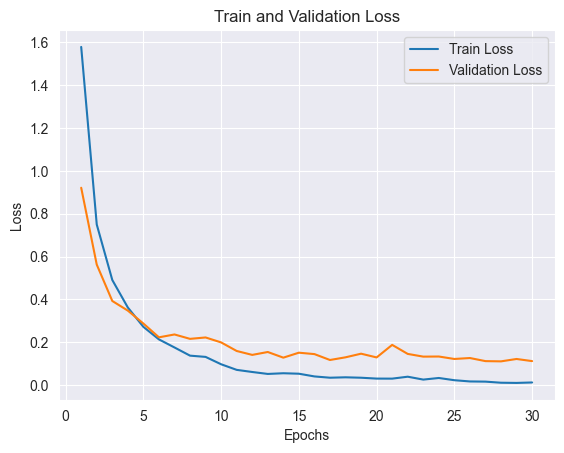

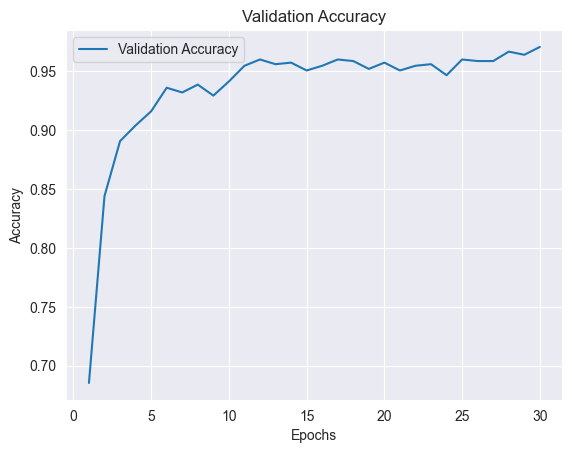

Accuracy: 0.9707, Precision: 0.9715, Recall: 0.9707, F1-score: 0.9707


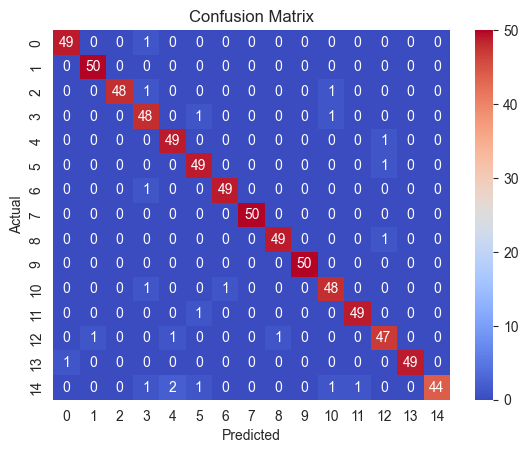

In [52]:
## Select your best model with respect to validation accuracy
## Visualize the accuracy and loss change of the best performing model across training and validation datasets.
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()
plt.show()
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()
## Compute metrics such as accuracy, precision, recall, and F1-score
## Visualize confusion matrix to understand the model's behavior across different classes
accuracy= accuracy_score(real_labels, predictions)
precision= precision_score(real_labels, predictions, average='weighted')
recall= recall_score(real_labels, predictions, average='weighted')
f1= f1_score(real_labels, predictions, average='weighted')
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
conf_matrix = confusion_matrix(real_labels, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 1.6 Evaluate the trained model on the test set (5 points)

In [53]:
class TestDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.image_paths = sorted(glob.glob(f"{folder_path}/*"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, path

test_dataset = TestDataset(folder_path='./test_unlabeled_v2', transform=transformations)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch, shuffle=False)

model.eval()
test_predictions = []
test_image_names = []

with torch.no_grad():
    for inputs, paths in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        test_predictions.extend(predicted.cpu().numpy())
        batch_names = [p.replace('\\', '/').split('/')[-1] for p in paths]
        test_image_names.extend(batch_names)

class_names = train_dataset.classes
predicted_labels = [class_names[pred] for pred in test_predictions]

submission_df = pd.DataFrame({'Id': test_image_names, 'label': predicted_labels})
submission_df.to_csv('cnn.csv', index=False)

### 1.7 Conclusion and interpretation (7 points)
**Summarize the performance of the model on the test set**

* The Convolutional Neural Network (CNN) demonstrated highly effective classification capabilities, achieving a final accuracy of 97.3% on the unseen test set. Other metrics like F1-score are also successful. Reviewing the training progression, the model showed consistent improvement, breaking the 90% accuracy barrier as early as Epoch 4. By Epoch 30, the model achieved a Validation Accuracy of 97.07% and a Validation Loss of 0.1116. The close alignment between the final validation metrics and the test set performance indicates that the model generalizes well to new data.

**Discuss any challenges encountered during training and potential areas for improvement**

* The primary challenge encountered during the training process was the model's tendency toward overfitting, accompanied by volatility in loss and accuracy metrics during earlier iterations. To mitigate the model's inclination to memorize the training data rather than learning generalizable features, a comprehensive set of regularization and optimization strategies was implemented. Specifically, data augmentation techniques, such as random rotations, were applied to input images to artificially expand the diversity of the training dataset. Concurrently, architectural adjustments including Dropout layers and weight_decay were introduced to penalize model complexity. To further stabilize the learning process and ensure faster convergence, BatchNorm2d was utilized. A discrete GPU was used to manage the computational intensity of the prolonged training duration.

**Reflect on the overall effectiveness of the chosen CNN architecture and training approach**

* Reflecting on the overall performance, the chosen CNN architecture proved to be highly effective for this classification task, evidenced by the rapid and significant decrease in training loss from 1.57 to 0.01. However, a detailed analysis of the final epochs reveals a slight divergence indicative of mild overfitting. While the Training Loss approached near-zero values (0.0118 at Epoch 30), the Validation Loss stuck in the 0.11–0.12 range. This observed "gap" suggests that while the regularization techniques were largely successful, the model retains a slight bias toward the training data. Future iterations could arguably benefit from implementing  more aggressive data augmentation techniques to further bridge the discrepancy between training and validation performance.

### 1.8 Kaggle Test Result (5 points)
**Put your Kaggle test result for your CNN model here.**

**You will get a score between 0-1 and your percentage (e.g. 0.1, 0.3, 0.6, 0.85) of accuracy will be multiplied by the highest possible score (5 points) for this part. That will be your grading score.**

* Kaggle Score: 0.973


## 2. Exploring Transfer Learning with ResNet50 and MobileNet (60 points)

### 2.1. Introduction
**Brief overview of the task.**

* This task explores the application of Transfer Learning to classify images from the Vegetable Image Dataset. We utilize two pre-trained architectures, ResNet-18 and MobileNet, applying various fine-tuning strategies to compare their performance against a custom CNN trained from scratch.

**Answer the questions like, What is fine-tuning? Why should we do this? Why do we freeze the rest and train only last layers?**

* Fine-tuning is a technique where a model pre-trained on a large-scale dataset  is repurposed for a specific target task. Instead of initializing a network with random weights, we use the pre-trained weights as a starting point and update them to minimize loss on the new dataset. Training deep networks from scratch requires massive datasets and significant computational power to prevent overfitting. Transfer learning overcomes this by leveraging previously learned feature representations. It allows for faster convergence and higher accuracy, particularly when the target dataset has limited labeled examples.Freezing the earlier layers of a pre-trained model and training only the last layers is done to retain the general feature extraction capabilities learned from a large dataset  while adapting the model to the specific target dataset. The earlier layers capture low-level features like edges and textures, which are generally applicable across tasks, whereas the last layers are task-specific. By freezing the earlier layers, we reduce computational cost, prevent overfitting, and focus on fine-tuning the model for the new task.

### 2.2. Load the pre-trained ResNet18 model (3 points)


In [54]:
## Utilize torchvision library to load the pre-trained ResNet50 model
## Ensure that the model's architecture matches ResNet50, by checking the model summary.
set_seed(42)
resnet18_model1 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
print(resnet18_model1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 2.3 Modify the ResNet18 model for transfer learning (15 points)

Epoch [1/29], Train Loss: 1.8619, Validation Loss: 1.0697
Accuracy: 0.8947
Epoch [2/29], Train Loss: 0.8056, Validation Loss: 0.5394
Accuracy: 0.9440
Epoch [3/29], Train Loss: 0.4830, Validation Loss: 0.3541
Accuracy: 0.9707
Epoch [4/29], Train Loss: 0.3531, Validation Loss: 0.2704
Accuracy: 0.9707
Epoch [5/29], Train Loss: 0.2882, Validation Loss: 0.2165
Accuracy: 0.9787
Epoch [6/29], Train Loss: 0.2403, Validation Loss: 0.1821
Accuracy: 0.9813
Epoch [7/29], Train Loss: 0.2014, Validation Loss: 0.1491
Accuracy: 0.9827
Epoch [8/29], Train Loss: 0.1728, Validation Loss: 0.1422
Accuracy: 0.9787
Epoch [9/29], Train Loss: 0.1506, Validation Loss: 0.1257
Accuracy: 0.9867
Epoch [10/29], Train Loss: 0.1383, Validation Loss: 0.1207
Accuracy: 0.9880
Epoch [11/29], Train Loss: 0.1227, Validation Loss: 0.0950
Accuracy: 0.9907
Epoch [12/29], Train Loss: 0.1183, Validation Loss: 0.0877
Accuracy: 0.9920
Epoch [13/29], Train Loss: 0.1061, Validation Loss: 0.0885
Accuracy: 0.9893
Epoch [14/29], Train 

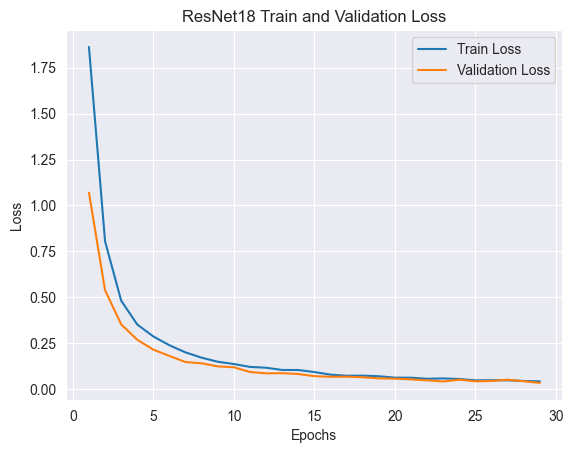

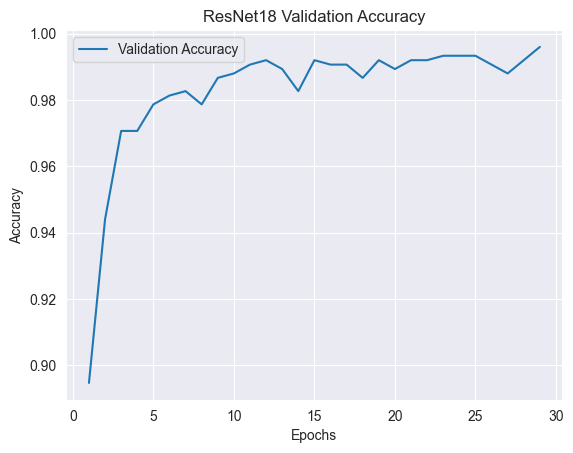

Accuracy: 0.9960, Precision: 0.9961, Recall: 0.9960, F1-score: 0.9960


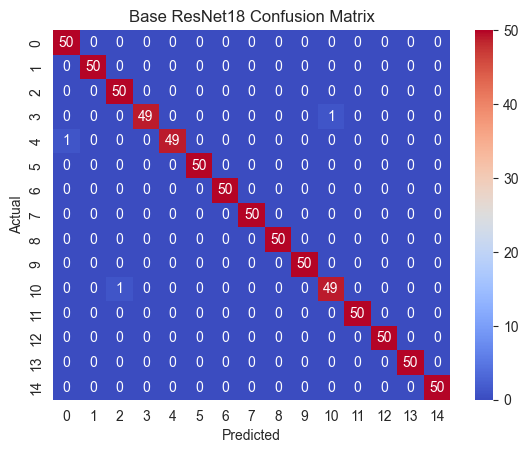

In [55]:
## Freeze all layers of the ResNet18 model.
## Replace the final fully connected layer with a new FC layer matching the number of classes
## Unfreeze the final FC layer
## Define appropriate loss function and optimizer for training
## Train the modified ResNet18 model on the vegetable image dataset. (base model)
for param in resnet18_model1.parameters():
    param.requires_grad = False
resnet18_model1.fc = nn.Linear(resnet18_model1.fc.in_features, 15) # 15 classes
for param in resnet18_model1.fc.parameters():
    param.requires_grad = True
loss_function_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet18_model1.fc.parameters(), lr=0.0005, weight_decay=1e-5)


resnet18_model1 = resnet18_model1.to(device)
num_epochs = 29
train_losses_model1 = []
val_losses_model1 = []
accuracies_model1 = []

for epoch in range(num_epochs):
    resnet18_model1.train()
    train_loss_resnet = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = resnet18_model1(inputs)
        loss = loss_function_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        train_loss_resnet += loss.item()
    avg_loss_resnet = train_loss_resnet / len(train_loader)
    train_losses_model1.append(avg_loss_resnet)

    resnet18_model1.eval()
    val_loss_resnet = 0.0
    real_labels_resnet = []
    predictions_resnet = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet18_model1(inputs)
            loss = loss_function_resnet(outputs, labels)
            val_loss_resnet += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            real_labels_resnet.extend(labels.cpu().numpy())
            predictions_resnet.extend(predicted.cpu().numpy())
    avg_val_loss_resnet = val_loss_resnet / len(val_loader)
    val_losses_model1.append(avg_val_loss_resnet)
    accuracy = accuracy_score(real_labels_resnet, predictions_resnet)
    accuracies_model1.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss_resnet:.4f}, Validation Loss: {avg_val_loss_resnet:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

plt.plot(range(1, num_epochs + 1), train_losses_model1, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses_model1, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet18 Train and Validation Loss')
plt.legend()
plt.show()

plt.plot(range(1, num_epochs + 1), accuracies_model1, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet18 Validation Accuracy')
plt.legend()
plt.show()

accuracy_resnet = accuracy_score(real_labels_resnet, predictions_resnet)
precision_resnet = precision_score(real_labels_resnet, predictions_resnet, average='weighted')
recall_resnet = recall_score(real_labels_resnet, predictions_resnet, average='weighted')
f1_resnet = f1_score(real_labels_resnet, predictions_resnet, average='weighted')
print(f"Accuracy: {accuracy_resnet:.4f}, Precision: {precision_resnet:.4f}, Recall: {recall_resnet:.4f}, F1-score: {f1_resnet:.4f}")

conf_matrix_resnet = confusion_matrix(real_labels_resnet, predictions_resnet)
sns.heatmap(conf_matrix_resnet, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Base ResNet18 Confusion Matrix')
plt.show()

In [70]:
set_seed(42) # reset seed

Epoch [1/6], Train Loss: 0.5103, Validation Loss: 0.0469
Accuracy: 0.9960
Epoch [2/6], Train Loss: 0.0383, Validation Loss: 0.0228
Accuracy: 0.9960
Epoch [3/6], Train Loss: 0.0151, Validation Loss: 0.0148
Accuracy: 0.9987
Epoch [4/6], Train Loss: 0.0089, Validation Loss: 0.0080
Accuracy: 0.9987
Epoch [5/6], Train Loss: 0.0075, Validation Loss: 0.0087
Accuracy: 0.9973
Epoch [6/6], Train Loss: 0.0051, Validation Loss: 0.0050
Accuracy: 1.0000


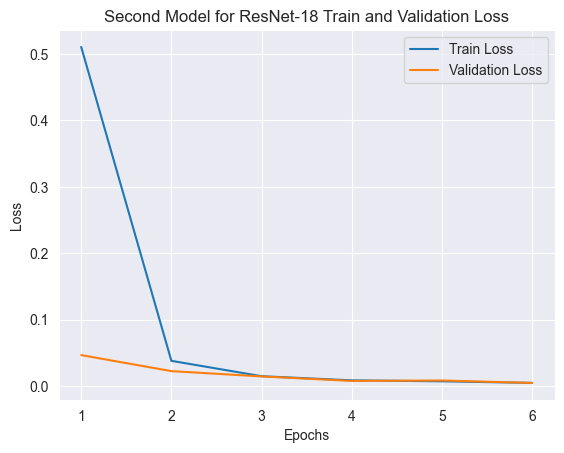

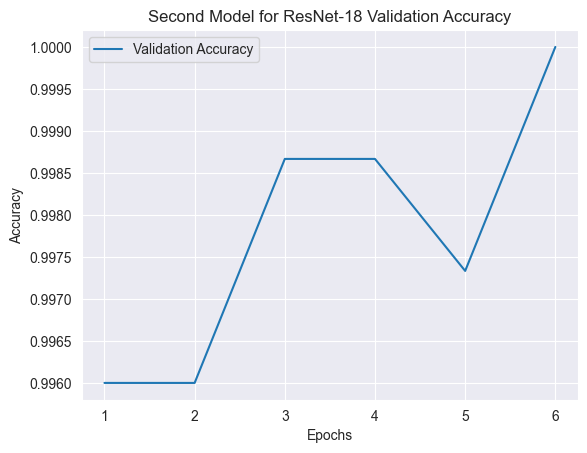

Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000


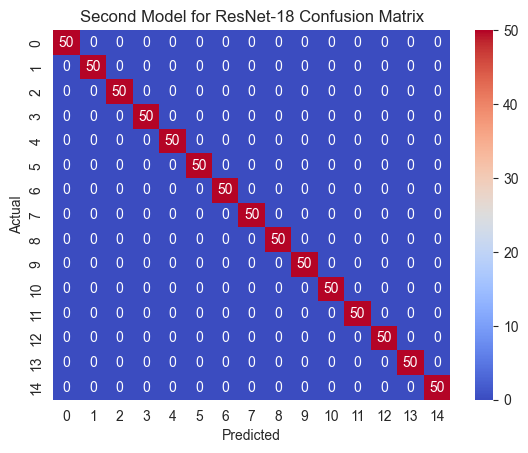

In [71]:
## Define another ResNet18 model
## Freeze all layers of the ResNet18 model.
## Replace the final fully connected layer with a new FC layer matching the number of classes
## Unfreeze the final FC layer
## Unfreeze convolutional layers 3 and 4 of the ResNet18 model and again proceed with training. (second model)
resnet18_model2 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
for param in resnet18_model2.parameters():
    param.requires_grad = False
resnet18_model2.fc = nn.Linear(resnet18_model2.fc.in_features, 15)
for param in resnet18_model2.fc.parameters():
    param.requires_grad = True
for param in resnet18_model2.layer3.parameters():
    param.requires_grad = True
for param in resnet18_model2.layer4.parameters():
    param.requires_grad = True
optimizer_resnet2 = optim.Adam(filter(lambda p: p.requires_grad, resnet18_model2.parameters()), lr=0.0001, weight_decay=1e-5)
resnet18_model2 = resnet18_model2.to(device)
num_epochs = 6
train_losses_model2 = []
val_losses_model2 = []
accuracies_model2 = []

for epoch in range(num_epochs):
    resnet18_model2.train()
    train_loss_resnet2 = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_resnet2.zero_grad()
        outputs = resnet18_model2(inputs)
        loss = loss_function_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet2.step()
        train_loss_resnet2 += loss.item()
    avg_loss_resnet2 = train_loss_resnet2 / len(train_loader)
    train_losses_model2.append(avg_loss_resnet2)
    resnet18_model2.eval()
    val_loss_resnet2 = 0.0
    real_labels_resnet2 = []
    predictions_resnet2 = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet18_model2(inputs)
            loss = loss_function_resnet(outputs, labels)
            val_loss_resnet2 += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            real_labels_resnet2.extend(labels.cpu().numpy())
            predictions_resnet2.extend(predicted.cpu().numpy())
    avg_val_loss_resnet2 = val_loss_resnet2 / len(val_loader)
    val_losses_model2.append(avg_val_loss_resnet2)
    accuracy = accuracy_score(real_labels_resnet2, predictions_resnet2)
    accuracies_model2.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss_resnet2:.4f}, Validation Loss: {avg_val_loss_resnet2:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
plt.plot(range(1, num_epochs + 1), train_losses_model2, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses_model2, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Second Model for ResNet-18 Train and Validation Loss')
plt.legend()
plt.show()
plt.plot(range(1, num_epochs + 1), accuracies_model2, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Second Model for ResNet-18 Validation Accuracy')
plt.legend()
plt.show()
accuracy_resnet2 = accuracy_score(real_labels_resnet2, predictions_resnet2)
precision_resnet2 = precision_score(real_labels_resnet2, predictions_resnet2, average='weighted')
recall_resnet2 = recall_score(real_labels_resnet2, predictions_resnet2, average='weighted')
f1_resnet2 = f1_score(real_labels_resnet2, predictions_resnet2, average='weighted')
print(f"Accuracy: {accuracy_resnet2:.4f}, Precision: {precision_resnet2:.4f}, Recall: {recall_resnet2:.4f}, F1-score: {f1_resnet2:.4f}")
conf_matrix_resnet2 = confusion_matrix(real_labels_resnet2, predictions_resnet2)
sns.heatmap(conf_matrix_resnet2, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Second Model for ResNet-18 Confusion Matrix')
plt.show()

In [58]:
set_seed(42) # reset seed

Epoch [1/15], Train Loss: 0.8243, Validation Loss: 0.1115
Accuracy: 0.9960
Epoch [2/15], Train Loss: 0.0955, Validation Loss: 0.0425
Accuracy: 0.9933
Epoch [3/15], Train Loss: 0.0366, Validation Loss: 0.0239
Accuracy: 0.9987
Epoch [4/15], Train Loss: 0.0214, Validation Loss: 0.0145
Accuracy: 0.9973
Epoch [5/15], Train Loss: 0.0159, Validation Loss: 0.0133
Accuracy: 0.9973
Epoch [6/15], Train Loss: 0.0118, Validation Loss: 0.0084
Accuracy: 1.0000
Epoch [7/15], Train Loss: 0.0078, Validation Loss: 0.0076
Accuracy: 0.9987
Epoch [8/15], Train Loss: 0.0062, Validation Loss: 0.0120
Accuracy: 0.9960
Epoch [9/15], Train Loss: 0.0050, Validation Loss: 0.0102
Accuracy: 0.9960
Epoch [10/15], Train Loss: 0.0050, Validation Loss: 0.0077
Accuracy: 0.9987
Epoch [11/15], Train Loss: 0.0038, Validation Loss: 0.0075
Accuracy: 0.9987
Epoch [12/15], Train Loss: 0.0035, Validation Loss: 0.0065
Accuracy: 0.9973
Epoch [13/15], Train Loss: 0.0029, Validation Loss: 0.0044
Accuracy: 1.0000
Epoch [14/15], Train 

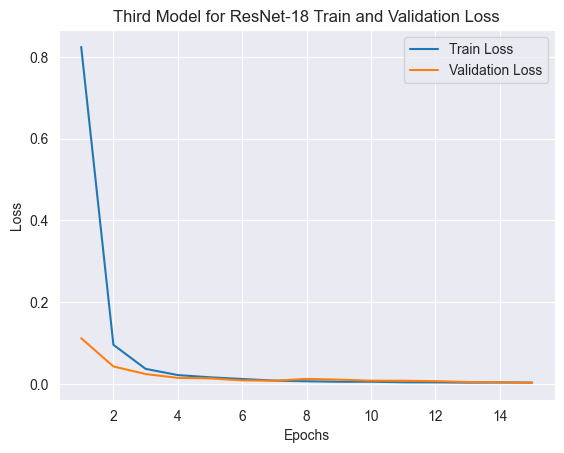

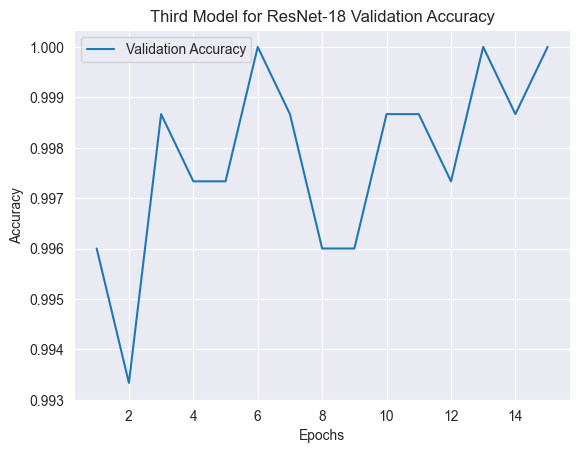

Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000


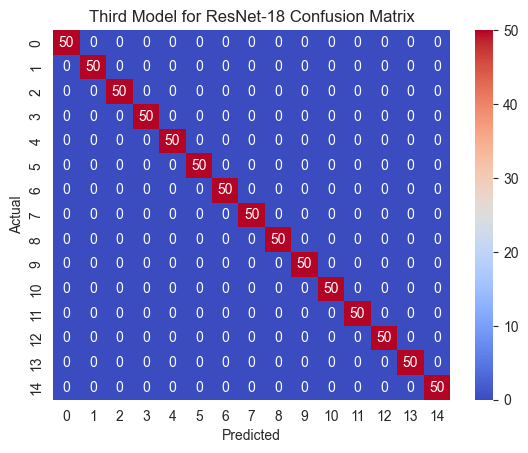

In [59]:
## Define another ResNet18 model
## Replace the final fully connected layer with a new FC layer matching the number of classes proceed with training. (third model)
## Define appropriate loss function and optimizer for training
## Iterate over the training dataset in mini-batches, compute the loss, and update model parameters.
## Monitor the training process and evaluate all model's performance on the validation set periodically.
## Visualize the accuracy and loss changes of the models across training and validation datasets.

## Compute metrics such as accuracy, precision, recall, and F1-score to assess classification performance.
## Visualize confusion matrix to understand the model's behavior across different classes
resnet18_model3 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet18_model3.fc = nn.Linear(resnet18_model3.fc.in_features, 15)
resnet18_model3 = resnet18_model3.to(device)
optimizer_resnet3 = optim.Adam(resnet18_model3.parameters(), lr=0.00005, weight_decay=1e-5)
num_epochs = 15
train_losses_model3 = []
val_losses_model3 = []
accuracies_model3 = []

for epoch in range(num_epochs):
    resnet18_model3.train()
    train_loss_resnet3 = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_resnet3.zero_grad()
        outputs = resnet18_model3(inputs)
        loss = loss_function_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet3.step()
        train_loss_resnet3 += loss.item()
    avg_loss_resnet3 = train_loss_resnet3 / len(train_loader)
    train_losses_model3.append(avg_loss_resnet3)
    resnet18_model3.eval()
    val_loss_resnet3 = 0.0
    real_labels_resnet3 = []
    predictions_resnet3 = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet18_model3(inputs)
            loss = loss_function_resnet(outputs, labels)
            val_loss_resnet3 += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            real_labels_resnet3.extend(labels.cpu().numpy())
            predictions_resnet3.extend(predicted.cpu().numpy())
    avg_val_loss_resnet3 = val_loss_resnet3 / len(val_loader)
    val_losses_model3.append(avg_val_loss_resnet3)
    accuracy = accuracy_score(real_labels_resnet3, predictions_resnet3)
    accuracies_model3.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss_resnet3:.4f}, Validation Loss: {avg_val_loss_resnet3:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
plt.plot(range(1, num_epochs + 1), train_losses_model3, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses_model3, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Third Model for ResNet-18 Train and Validation Loss')
plt.legend()
plt.show()

plt.plot(range(1, num_epochs + 1), accuracies_model3, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Third Model for ResNet-18 Validation Accuracy')
plt.legend()
plt.show()
accuracy_resnet3 = accuracy_score(real_labels_resnet3, predictions_resnet3)
precision_resnet3 = precision_score(real_labels_resnet3, predictions_resnet3, average='weighted')
recall_resnet3 = recall_score(real_labels_resnet3, predictions_resnet3, average='weighted')
f1_resnet3 = f1_score(real_labels_resnet3, predictions_resnet3, average='weighted')
print(f"Accuracy: {accuracy_resnet3:.4f}, Precision: {precision_resnet3:.4f}, Recall: {recall_resnet3:.4f}, F1-score: {f1_resnet3:.4f}")

conf_matrix_resnet3 = confusion_matrix(real_labels_resnet3, predictions_resnet3)
sns.heatmap(conf_matrix_resnet3, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Third Model for ResNet-18 Confusion Matrix')
plt.show()

Conduct a comparative analysis among these three models. Comment on their performance and select your best model with respect to validation accuracy.
* Which model performed better and why do you think it performed better?  
* Comment on the practical considerations among these models also.

**Comparative Analysis of the Three ResNet-18 Models:**

* Based on the validation metrics, the third model (fine-tuning all weights) is the superior choice, achieving perfect 100% accuracy with the lowest validation loss of 0.0022, compared to 0.0050 for the second model and 0.0356 for the base model. While the second model (fine-tuning Blocks 3, 4, and FC) was the most computationally efficient, converging to 100% accuracy in just 6 epochs, the third model's lower loss indicates a more robust adaptation of the feature extraction layers to the specific dataset, resulting in higher confidence predictions. In contrast, the base model (FC only) was the least effective, requiring 29 epochs to reach only 99.60% accuracy, demonstrating that adjusting only the final layer is insufficient for maximizing performance on this specific task compared to deep feature adaptation.
* The choice of model depends on the specific constraints of the application environment. Model 1 is the most resource friendly in terms of memory usage per step, making it suitable for hardware with extremely limited , though this comes at the cost of slow convergence (29 epochs) and suboptimal accuracy. Model 2  offers the best efficiency to performance ratio, it provided the fastest convergence (reaching 100% accuracy in just 6 epochs), making it the ideal candidate for rapid prototyping or scenarios where training time is a critical bottleneck. However, for applications where precision is paramount, Model 3 remains the optimal choice despite being the most computationally expensive per epoch, as it delivers the highest reliability (lowest loss) by fully adapting the network's deep features to the new dataset.

### 2.4 Evaluate the fine-tuned ResNet18 model (5 points)

In [60]:
## Test the best model on the test set to evaluate its performance.
## Comment on the results
## Compare the fine-tuned ResNet18 model performance with the CNN model implemented from scratch
resnet18_model_best = resnet18_model3
resnet18_model_best.eval()
test_predictions_resnet = []
test_image_names_resnet = []
with torch.no_grad():
    for inputs, paths in test_loader:
        inputs = inputs.to(device)
        outputs = resnet18_model_best(inputs)
        _, predicted = torch.max(outputs.data, 1)

        test_predictions_resnet.extend(predicted.cpu().numpy())
        batch_names = [p.replace('\\', '/').split('/')[-1] for p in paths]
        test_image_names_resnet.extend(batch_names)
class_names = train_dataset.classes
predicted_labels_resnet = [class_names[pred] for pred in test_predictions_resnet]
submission_df_resnet = pd.DataFrame({'Id': test_image_names_resnet, 'label': predicted_labels_resnet})
submission_df_resnet.to_csv('resnet18.csv', index=False)

### 2.5 Kaggle Test Result (5 points)
**Put your Kaggle test result for your ResNet-18 pretrained model here.**

**You will get a score between 0-1 and your percentage (e.g. 0.1, 0.3, 0.6, 0.85) of accuracy will be multiplied by the highest possible score (5 points) for this part. That will be your grading score.**

* Kaggle Score: 0.995

### 2.7. Load the pre-trained MobileNet model (3 points)


In [61]:
## Utilize torchvision library to load the pre-trained MobileNetV2 model
## Ensure that the model's architecture matches MobileNetV2, by checking the model summary.
set_seed(42)
mobilenet_model = torchvision.models.mobilenet_v2(weights=torchvision.models.MobileNet_V2_Weights.DEFAULT)
print(mobilenet_model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

### 2.8 Modify the MobileNet model for transfer learning (12 points)

Epoch [1/28], Train Loss: 1.9693, Validation Loss: 1.3013
Accuracy: 0.9267
Epoch [2/28], Train Loss: 1.0184, Validation Loss: 0.7643
Accuracy: 0.9413
Epoch [3/28], Train Loss: 0.6436, Validation Loss: 0.5099
Accuracy: 0.9573
Epoch [4/28], Train Loss: 0.4698, Validation Loss: 0.3704
Accuracy: 0.9733
Epoch [5/28], Train Loss: 0.3823, Validation Loss: 0.2985
Accuracy: 0.9747
Epoch [6/28], Train Loss: 0.3057, Validation Loss: 0.2486
Accuracy: 0.9867
Epoch [7/28], Train Loss: 0.2648, Validation Loss: 0.2063
Accuracy: 0.9827
Epoch [8/28], Train Loss: 0.2372, Validation Loss: 0.1868
Accuracy: 0.9760
Epoch [9/28], Train Loss: 0.2031, Validation Loss: 0.1689
Accuracy: 0.9853
Epoch [10/28], Train Loss: 0.1802, Validation Loss: 0.1436
Accuracy: 0.9880
Epoch [11/28], Train Loss: 0.1743, Validation Loss: 0.1265
Accuracy: 0.9933
Epoch [12/28], Train Loss: 0.1554, Validation Loss: 0.1168
Accuracy: 0.9893
Epoch [13/28], Train Loss: 0.1379, Validation Loss: 0.1087
Accuracy: 0.9907
Epoch [14/28], Train 

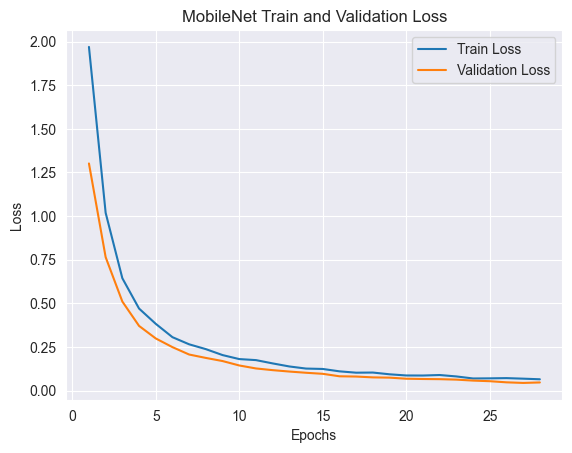

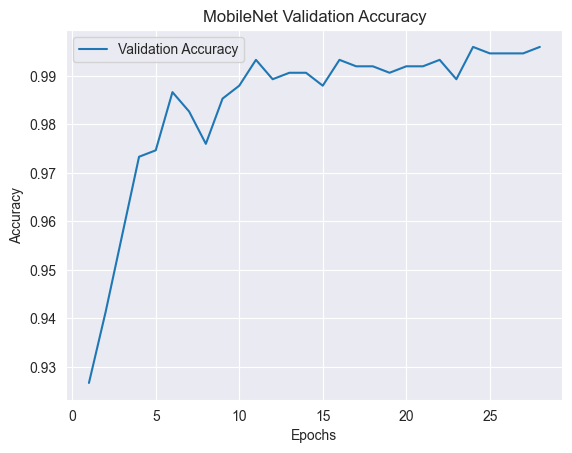

Accuracy: 0.9960, Precision: 0.9961, Recall: 0.9960, F1-score: 0.9960


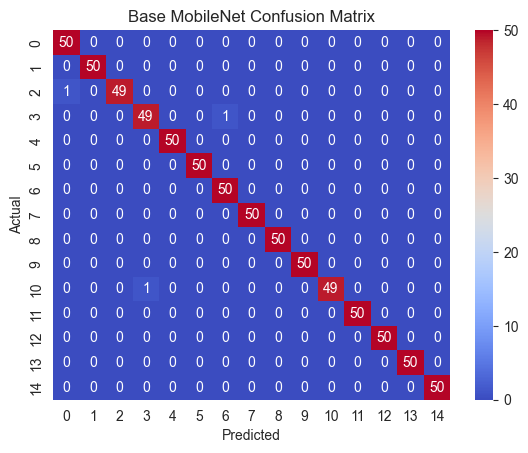

In [62]:
## Freeze all layers of the MobileNet model.
## Replace the final fully connected layer with a new FC layer matching the number of classes
## Unfreeze the final FC layer
## Define appropriate loss function and optimizer for training
## Train the modified MobileNet model on the vegetable image dataset. (base model)
for param in mobilenet_model.parameters():
    param.requires_grad = False
mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.classifier[1].in_features, 15)
for param in mobilenet_model.classifier[1].parameters():
    param.requires_grad = True
optimizer_mobilenet = optim.Adam(mobilenet_model.classifier[1].parameters(), lr=0.0005, weight_decay=1e-5)
mobilenet_model = mobilenet_model.to(device)
num_epochs = 28
train_losses_mobilenet1 = []
val_losses_mobilenet = []
accuracies_mobilenet = []

for epoch in range(num_epochs):
    mobilenet_model.train()
    train_loss_mobilenet = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_mobilenet.zero_grad()
        outputs = mobilenet_model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer_mobilenet.step()
        train_loss_mobilenet += loss.item()
    avg_loss_mobilenet = train_loss_mobilenet / len(train_loader)
    train_losses_mobilenet1.append(avg_loss_mobilenet)

    mobilenet_model.eval()
    val_loss_mobilenet = 0.0
    real_labels_mobilenet = []
    predictions_mobilenet = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mobilenet_model(inputs)
            loss = loss_function(outputs, labels)
            val_loss_mobilenet += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            real_labels_mobilenet.extend(labels.cpu().numpy())
            predictions_mobilenet.extend(predicted.cpu().numpy())
    avg_val_loss_mobilenet = val_loss_mobilenet / len(val_loader)
    val_losses_mobilenet.append(avg_val_loss_mobilenet)
    accuracy = accuracy_score(real_labels_mobilenet, predictions_mobilenet)
    accuracies_mobilenet.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss_mobilenet:.4f}, Validation Loss: {avg_val_loss_mobilenet:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
plt.plot(range(1, num_epochs + 1), train_losses_mobilenet1, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses_mobilenet, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MobileNet Train and Validation Loss')
plt.legend()
plt.show()

plt.plot(range(1, num_epochs + 1), accuracies_mobilenet, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MobileNet Validation Accuracy')
plt.legend()
plt.show()

accuracy_mobilenet = accuracy_score(real_labels_mobilenet, predictions_mobilenet)
precision_mobilenet = precision_score(real_labels_mobilenet, predictions_mobilenet, average='weighted')
recall_mobilenet = recall_score(real_labels_mobilenet, predictions_mobilenet, average='weighted')
f1_mobilenet = f1_score(real_labels_mobilenet, predictions_mobilenet, average='weighted')
print(f"Accuracy: {accuracy_mobilenet:.4f}, Precision: {precision_mobilenet:.4f}, Recall: {recall_mobilenet:.4f}, F1-score: {f1_mobilenet:.4f}")

conf_matrix_mobilenet = confusion_matrix(real_labels_mobilenet, predictions_mobilenet)
sns.heatmap(conf_matrix_mobilenet, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Base MobileNet Confusion Matrix')
plt.show()

In [63]:
set_seed(42) # reset seed

Epoch [1/34], Train Loss: 2.2845, Validation Loss: 1.5720
Accuracy: 0.8880
Epoch [2/34], Train Loss: 1.0172, Validation Loss: 0.4803
Accuracy: 0.9733
Epoch [3/34], Train Loss: 0.3791, Validation Loss: 0.1792
Accuracy: 0.9907
Epoch [4/34], Train Loss: 0.1918, Validation Loss: 0.0864
Accuracy: 0.9947
Epoch [5/34], Train Loss: 0.1256, Validation Loss: 0.0591
Accuracy: 0.9920
Epoch [6/34], Train Loss: 0.0729, Validation Loss: 0.0379
Accuracy: 0.9973
Epoch [7/34], Train Loss: 0.0590, Validation Loss: 0.0262
Accuracy: 0.9987
Epoch [8/34], Train Loss: 0.0483, Validation Loss: 0.0263
Accuracy: 0.9947
Epoch [9/34], Train Loss: 0.0349, Validation Loss: 0.0235
Accuracy: 0.9933
Epoch [10/34], Train Loss: 0.0254, Validation Loss: 0.0158
Accuracy: 0.9987
Epoch [11/34], Train Loss: 0.0217, Validation Loss: 0.0104
Accuracy: 1.0000
Epoch [12/34], Train Loss: 0.0241, Validation Loss: 0.0120
Accuracy: 0.9987
Epoch [13/34], Train Loss: 0.0156, Validation Loss: 0.0110
Accuracy: 0.9973
Epoch [14/34], Train 

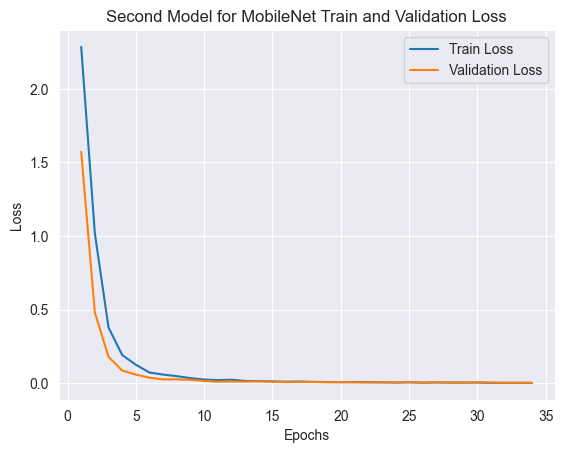

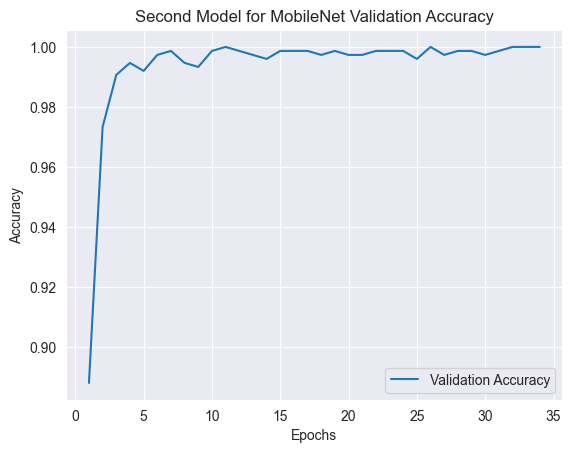

Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000


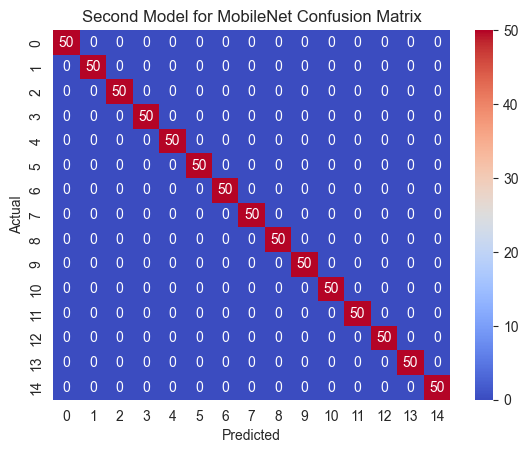

In [64]:
## Define another MobileNet model
## Replace the final fully connected layer with a new FC layer matching the number of classes proceed with training. (second model)
## Define appropriate loss function and optimizer for training
## Iterate over the training dataset in mini-batches, compute the loss, and update model parameters.
## Monitor the training process and evaluate all model's performance on the validation set periodically.
## Visualize the accuracy and loss changes of the models across training and validation datasets.
## Compute metrics such as accuracy, precision, recall, and F1-score to assess classification performance.
## Visualize confusion matrix to understand the model's behavior across different classes
mobilenet_model2 = torchvision.models.mobilenet_v2(weights=torchvision.models.MobileNet_V2_Weights.DEFAULT)
mobilenet_model2.classifier[1] = nn.Linear(mobilenet_model2.classifier[1].in_features, 15)
mobilenet_model2 = mobilenet_model2.to(device)
optimizer_mobilenet2 = optim.Adam(mobilenet_model2.parameters(), lr=0.00005, weight_decay=1e-5)
num_epochs = 34
train_losses_mobilenet2 = []
val_losses_mobilenet2 = []
accuracies_mobilenet2 = []

for epoch in range(num_epochs):
    mobilenet_model2.train()
    train_loss_mobilenet2 = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_mobilenet2.zero_grad()
        outputs = mobilenet_model2(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer_mobilenet2.step()
        train_loss_mobilenet2 += loss.item()
    avg_loss_mobilenet2 = train_loss_mobilenet2 / len(train_loader)
    train_losses_mobilenet2.append(avg_loss_mobilenet2)

    mobilenet_model2.eval()
    val_loss_mobilenet2 = 0.0
    real_labels_mobilenet2 = []
    predictions_mobilenet2 = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mobilenet_model2(inputs)
            loss = loss_function(outputs, labels)
            val_loss_mobilenet2 += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            real_labels_mobilenet2.extend(labels.cpu().numpy())
            predictions_mobilenet2.extend(predicted.cpu().numpy())
    avg_val_loss_mobilenet2 = val_loss_mobilenet2 / len(val_loader)
    val_losses_mobilenet2.append(avg_val_loss_mobilenet2)
    accuracy = accuracy_score(real_labels_mobilenet2, predictions_mobilenet2)
    accuracies_mobilenet2.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss_mobilenet2:.4f}, Validation Loss: {avg_val_loss_mobilenet2:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

plt.plot(range(1, num_epochs + 1), train_losses_mobilenet2, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses_mobilenet2, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Second Model for MobileNet Train and Validation Loss')
plt.legend()
plt.show()

plt.plot(range(1, num_epochs + 1), accuracies_mobilenet2, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Second Model for MobileNet Validation Accuracy')
plt.legend()
plt.show()
accuracy_mobilenet2 = accuracy_score(real_labels_mobilenet2, predictions_mobilenet2)
precision_mobilenet2 = precision_score(real_labels_mobilenet2, predictions_mobilenet2, average='weighted')
recall_mobilenet2 = recall_score(real_labels_mobilenet2, predictions_mobilenet2, average='weighted')
f1_mobilenet2 = f1_score(real_labels_mobilenet2, predictions_mobilenet2, average='weighted')
print(f"Accuracy: {accuracy_mobilenet2:.4f}, Precision: {precision_mobilenet2:.4f}, Recall: {recall_mobilenet2:.4f}, F1-score: {f1_mobilenet2:.4f}")

conf_matrix_mobilenet2 = confusion_matrix(real_labels_mobilenet2, predictions_mobilenet2)
sns.heatmap(conf_matrix_mobilenet2, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Second Model for MobileNet Confusion Matrix')
plt.show()

Conduct a comparative analysis among these two models. Comment on their performance and select your best model with respect to validation accuracy.
* Which model performed better and why do you think it performed better?  
* Comment on the practical considerations among these models also.


**Comparative Analysis of the Two MobileNet Models:**

* Based on the validation metrics, the second model (fine-tuning all weights) is the superior choice, achieving perfect 100% accuracy with an exceptionally low validation loss of 0.0029, compared to 0.0463 for the base model. While the base model (fine-tuning only the FC layer) performed respectably, reaching 99.60% accuracy after 28 epochs, it plateaued with a significantly higher loss, indicating less certainty in its predictions. The second model, despite training for slightly longer (34 epochs), demonstrated a much steeper learning curve, reaching high accuracy (over 99%) by epoch 3 and ultimately minimizing the error to a near-zero value. This substantial difference in loss confirms that allowing the entire network to update its weights enabled it to learn features perfectly adapted to the specific dataset, whereas the base model was limited by the frozen feature extraction layers.
* From a deployment standpoint, Model 1 (FC Only) prioritizes computational efficiency by restricting gradient updates to the final layer, making it the preferred option for environments with limited hardware resources  or extremely small datasets where overfitting is a concern, however, this comes at the cost of higher validation loss  and slightly lower confidence compared to the fully trained variant. In contrast, Model 2 (Full Fine-tune) is the definitive choice for high-performance applications, as it achieves 100% accuracy and a superior validation loss of 0.0029 by adapting the entire network's weights to the specific dataset. Although Model 2 is computationally more expensive per epoch and carries a risk of catastrophic forgetting, its ability to learn deep, task-specific features makes it the most robust and reliable model when sufficient training resources are available.

### 2.9 Evaluate the fine-tuned MobileNet model (5 points)

In [72]:
## Test the best model on the test set to evaluate its performance.
## Comment on the results
mobilenet_model_best = mobilenet_model2
mobilenet_model_best.eval()
test_predictions_mobilenet = []
test_image_names_mobilenet = []
with torch.no_grad():
    for inputs, paths in test_loader:
        inputs = inputs.to(device)
        outputs = mobilenet_model_best(inputs)
        _, predicted = torch.max(outputs.data, 1)

        test_predictions_mobilenet.extend(predicted.cpu().numpy())
        batch_names = [p.replace('\\', '/').split('/')[-1] for p in paths]
        test_image_names_mobilenet.extend(batch_names)
class_names = train_dataset.classes
predicted_labels_mobilenet = [class_names[pred] for pred in test_predictions_mobilenet]
submission_df_mobilenet = pd.DataFrame({'Id': test_image_names_mobilenet, 'label': predicted_labels_mobilenet})
submission_df_mobilenet.to_csv('mobilenet.csv', index=False)

**Compare the best fine-tuned MobileNet model performance with the best CNN model implemented from scratch**

* The fine-tuned MobileNet vastly outperformed the custom CNN, achieving 100% accuracy and a minimal loss of 0.0029, compared to the CNN's peak of 97.07% and higher loss of 0.1116. MobileNet's use of transfer learning provided superior stability and generalization, whereas the scratch CNN struggled with overfitting and could not reach perfect classification.

**Compare the best fine-tuned MobileNet model performance with the best ResNet18 model implemented from scratch**

* Both models achieved perfect 100% accuracy, making them highly effective for this task. However, ResNet-18 demonstrated slightly higher statistical confidence with a lower validation loss of 0.0022 compared to MobileNet's 0.0029. While ResNet-18 is marginally "better" by metric, MobileNet offers the same accuracy with a more efficient, lightweight architecture.

### 2.10 Kaggle Test Result (5 points)
**Put your Kaggle test result for your MobileNet pretrained model here.**

**You will get a score between 0-1 and your percentage (e.g. 0.1, 0.3, 0.6, 0.85) of accuracy will be multiplied by the highest possible score (5 points) for this part. That will be your grading score.**

* Kaggle Score: 0.997


## 3 Analyze advantages and disadvantages (7 points)

**Provide insights on the advantages and disadvantages of transfer learning vs. training from scratch**

**Put a table for comparison of the best 3 models that you have obtained in this assignment (CNN from scratch, ResNet18, MobileNet)**

**Discuss practical considerations when choosing between these approaches and models.**

* The comparative results clearly demonstrate the superiority of transfer learning over training from scratch for this image classification task. The primary advantage of transfer learning (observed in the ResNet-18 and MobileNet experiments) is the ability to leverage pre-learned feature extractors trained on massive datasets like ImageNet. This allowed those models to achieve perfect 100% accuracy with extremely low loss values (0.0022 and 0.0029 respectively) and generally faster convergence. In contrast, training the CNN from scratch was significantly more challenging, the model started with a low accuracy of 68.53% and required 30 epochs to reach a peak of 97.07%. A major disadvantage of the scratch approach observed here is the higher risk of overfitting and instability, while the training loss continued to drop to near zero (0.0118), the validation loss remained high (0.1116) and fluctuated significantly after epoch 11. Transfer learning models, conversely, showed a much tighter correlation between training and validation loss, indicating better generalization.

* The following table summarizes the performance of the best models from each approach:
| Model Architecture | Training Strategy | Best Val Accuracy | Best Val Loss | Convergence Speed |
| :--- | :--- | :--- | :--- | :--- |
| **ResNet-18** | Full Fine-Tuning | **100.00%** | **0.0022** | Fast (15 Epochs) |
| **MobileNet** | Full Fine-Tuning | **100.00%** | 0.0029 | Moderate (34 Epochs) |
| **Custom CNN** | Trained from Scratch | 97.07% | 0.1116 | Slow (30 Epochs) |

* When choosing between these approaches, the decision involves balancing accuracy, computational efficiency, and data availability. ResNet-18 (Full Fine-tune) is the optimal choice for server-side deployments where computational resources are available, as it offers the highest statistical confidence (lowest loss) and fastest training convergence. MobileNet (Full Fine-tune) is the clear winner for edge or mobile deployment, it matches the ResNet in accuracy (100%) but is architecturally designed for efficiency with depth-wise separable convolutions, making it lighter to run during inference. The CNN from Scratch approach is generally the least favorable for this type of task, it should only be considered if the target domain is radically different from natural images ( specific medical or astronomical data) where ImageNet weights might be irrelevant, or if the model size must be microscopically small for extremely constrained hardware. However, as shown by the 97.07% accuracy cap and higher loss, it struggles to match the robustness of pre-trained networks on standard classification tasks.

